In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from matplotlib import pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train.shape

d:\Deep Learning\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)

In [3]:
X_test.shape

(10000, 32, 32, 3)

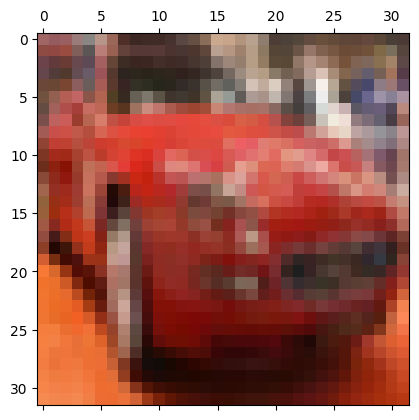

In [4]:
plt.matshow(X_train[5])

In [5]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [6]:
y_train = y_train.flatten()
y_train.shape

(50000,)

In [7]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
def plot_image(X, y, index):
    plt.matshow(X[index])
    plt.xlabel(classes[y[index]])

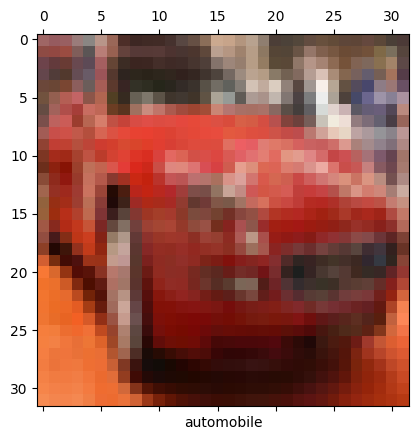

In [8]:
plot_image(X_train, y_train, 5)

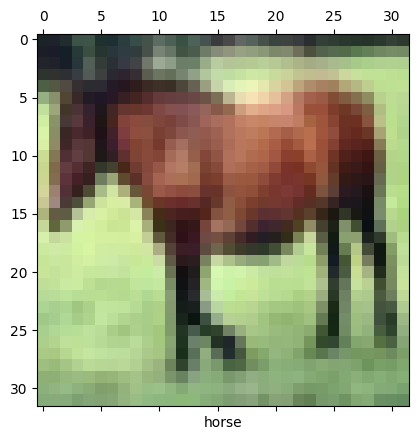

In [9]:
plot_image(X_train, y_train, 7)

**To scale it**

In [10]:
X_train = X_train/255
X_test = X_test/255

In [13]:
X_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

**First we gonna check how it is working on the ann**

In [18]:
model_ann = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Flatten(),
    keras.layers.Dense(2000, activation="relu"),
    keras.layers.Dense(1000, activation="relu"),
    keras.layers.Dense(10, activation="sigmoid")
])

model_ann.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model_ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 89ms/step - accuracy: 0.3307 - loss: 1.8695
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.3994 - loss: 1.6745
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 83ms/step - accuracy: 0.4286 - loss: 1.5956
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 126s 81ms/step - accuracy: 0.4457 - loss: 1.5490
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 81ms/step - accuracy: 0.4593 - loss: 1.5087


In [20]:
model_ann.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4587 - loss: 1.5364


[1.5364389419555664, 0.4587000012397766]

In [21]:
y_predicted_ann = model_ann.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [25]:
y_pred_ann = []
for i in y_predicted_ann:
    y_pred_ann.append(np.argmax(i))

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_ann))

              precision    recall  f1-score   support

           0       0.53      0.50      0.51      1000
           1       0.58      0.60      0.59      1000
           2       0.33      0.33      0.33      1000
           3       0.34      0.29      0.31      1000
           4       0.43      0.39      0.41      1000
           5       0.44      0.28      0.34      1000
           6       0.36      0.70      0.48      1000
           7       0.63      0.42      0.51      1000
           8       0.51      0.68      0.58      1000
           9       0.61      0.39      0.48      1000

    accuracy                           0.46     10000
   macro avg       0.48      0.46      0.45     10000
weighted avg       0.48      0.46      0.45     10000



**As we saw that ann performed very poor on the photo data we'll be using cnn now**

In [29]:
model_cnn = keras.Sequential([
    keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation="relu", input_shape=(32, 32, 3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(60, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model_cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model_cnn.fit(X_train, y_train, epochs=10)

d:\Deep Learning\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.4554 - loss: 1.5097
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.5903 - loss: 1.1588
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 18ms/step - accuracy: 0.6461 - loss: 1.0161
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.6732 - loss: 0.9343
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.6951 - loss: 0.8785
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7132 - loss: 0.8208
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7286 - loss: 0.7788
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7411 - loss: 0.7409
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - accuracy: 0.7563 - loss: 0.7019
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.7647 - loss: 0.6742


In [30]:
model_cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6896 - loss: 0.9595


[0.9594943523406982, 0.6895999908447266]

In [32]:
y_predicted_cnn = model_cnn.predict(X_test)
y_pred_cnn = []
for i in y_predicted_cnn:
    y_pred_cnn.append(np.argmax(i))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [33]:
print(classification_report(y_test, y_pred_cnn))

              precision    recall  f1-score   support

           0       0.70      0.75      0.73      1000
           1       0.79      0.83      0.81      1000
           2       0.58      0.61      0.60      1000
           3       0.62      0.35      0.45      1000
           4       0.74      0.48      0.58      1000
           5       0.62      0.61      0.62      1000
           6       0.61      0.89      0.72      1000
           7       0.73      0.77      0.75      1000
           8       0.74      0.85      0.79      1000
           9       0.78      0.75      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.68     10000
weighted avg       0.69      0.69      0.68     10000

